# Differential Equations with JAX

This notebook covers solving ordinary differential equations (ODEs) using JAX, with a focus on differentiable solvers that enable gradient-based optimization of dynamical systems.

**Topics covered:**
1. Basic ODE concepts and formulation
2. Simple Euler method implementation
3. Runge-Kutta methods (RK4)
4. Adaptive step size methods
5. Differentiating through ODE solutions
6. Parameter estimation in dynamical systems
7. Neural ODEs (introduction)
8. Using diffrax library

In [1]:
import jax
import jax.numpy as jnp
from jax import grad, jit, vmap, jacfwd
from jax import lax
import matplotlib.pyplot as plt
import numpy as np

# Enable 64-bit precision for better numerical accuracy
jax.config.update("jax_enable_x64", True)

## 1. ODE Basics

An ordinary differential equation (ODE) describes how a quantity changes over time:

$$\frac{dy}{dt} = f(t, y)$$

Given an initial condition $y(t_0) = y_0$, we want to find $y(t)$ for $t > t_0$.

### Example: Exponential Decay

The simplest ODE is exponential decay:
$$\frac{dy}{dt} = -k \cdot y$$

This has the analytical solution: $y(t) = y_0 \cdot e^{-kt}$

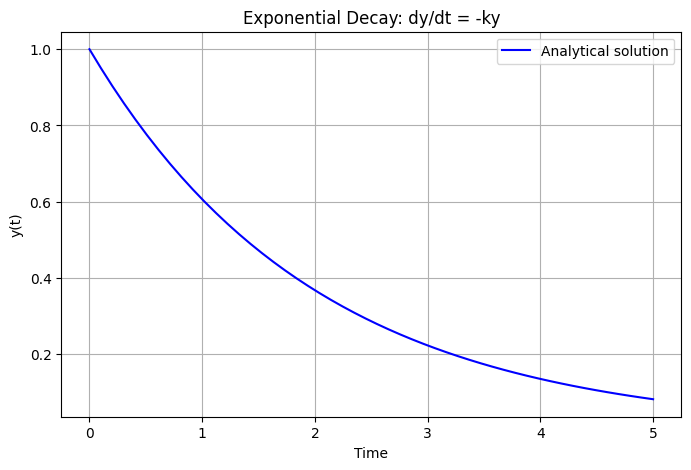

In [2]:
# Define the ODE right-hand side
def exponential_decay(t, y, k):
    """dy/dt = -k * y"""
    return -k * y

# Analytical solution for comparison
def analytical_solution(t, y0, k):
    return y0 * jnp.exp(-k * t)

# Test
k = 0.5
y0 = 1.0
t_test = jnp.linspace(0, 5, 50)
y_exact = analytical_solution(t_test, y0, k)

plt.figure(figsize=(8, 5))
plt.plot(t_test, y_exact, 'b-', label='Analytical solution')
plt.xlabel('Time')
plt.ylabel('y(t)')
plt.title('Exponential Decay: dy/dt = -ky')
plt.legend()
plt.grid(True)
plt.show()

## 2. Euler Method

The simplest numerical method for solving ODEs is **Euler's method**:

$$y_{n+1} = y_n + h \cdot f(t_n, y_n)$$

where $h$ is the step size. This is a first-order method (error scales as $O(h)$).

### Key insight for JAX:
We use `lax.scan` to implement the time-stepping loop efficiently and differentiably.

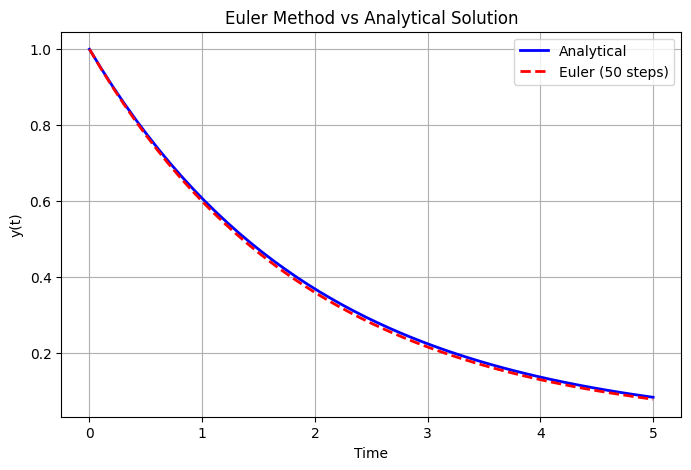

Final error with Euler: 0.005140


In [3]:
def euler_step(f, t, y, h, *args):
    """Single Euler step."""
    return y + h * f(t, y, *args)

def euler_solve(f, y0, t_span, n_steps, *args):
    """
    Solve ODE using Euler method.
    
    Args:
        f: ODE function f(t, y, *args)
        y0: Initial condition
        t_span: (t_start, t_end)
        n_steps: Number of time steps
        *args: Additional arguments to f
    
    Returns:
        t_values: Time points
        y_values: Solution at each time point
    """
    t_start, t_end = t_span
    h = (t_end - t_start) / n_steps
    t_values = jnp.linspace(t_start, t_end, n_steps + 1)
    
    def scan_fn(y, t):
        y_new = euler_step(f, t, y, h, *args)
        return y_new, y_new
    
    # Use lax.scan for efficient, differentiable iteration
    _, y_values = lax.scan(scan_fn, y0, t_values[:-1])
    
    # Prepend initial condition
    y_values = jnp.concatenate([y0[None], y_values])
    
    return t_values, y_values

# Solve exponential decay with Euler method
t_euler, y_euler = euler_solve(exponential_decay, jnp.array([y0]), (0.0, 5.0), 50, k)

plt.figure(figsize=(8, 5))
plt.plot(t_test, y_exact, 'b-', label='Analytical', linewidth=2)
plt.plot(t_euler, y_euler[:, 0], 'r--', label='Euler (50 steps)', linewidth=2)
plt.xlabel('Time')
plt.ylabel('y(t)')
plt.title('Euler Method vs Analytical Solution')
plt.legend()
plt.grid(True)
plt.show()

# Check error
final_error = jnp.abs(y_euler[-1, 0] - analytical_solution(5.0, y0, k))
print(f"Final error with Euler: {final_error:.6f}")

## 3. Runge-Kutta Methods (RK4)

The **4th-order Runge-Kutta method** is much more accurate (error $O(h^4)$):

$$k_1 = f(t_n, y_n)$$
$$k_2 = f(t_n + h/2, y_n + h k_1/2)$$
$$k_3 = f(t_n + h/2, y_n + h k_2/2)$$
$$k_4 = f(t_n + h, y_n + h k_3)$$
$$y_{n+1} = y_n + \frac{h}{6}(k_1 + 2k_2 + 2k_3 + k_4)$$

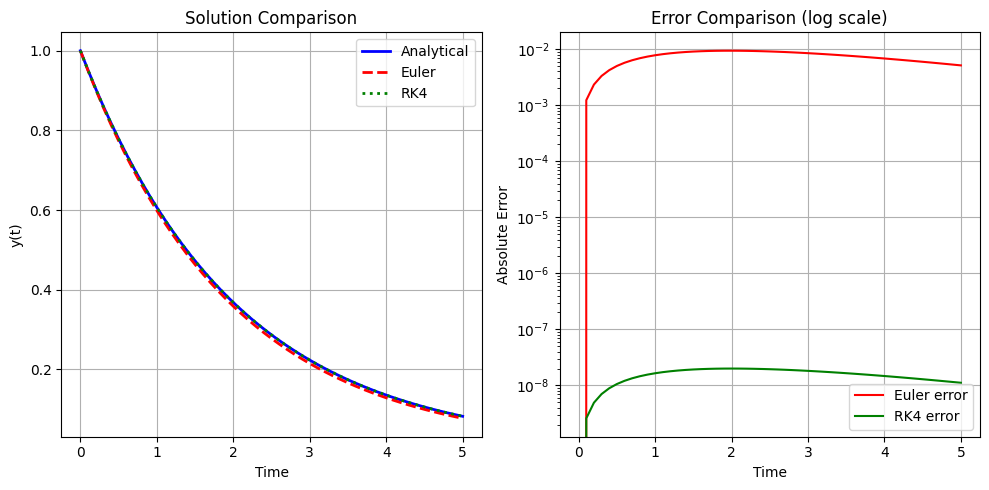

Final Euler error: 5.14e-03
Final RK4 error: 1.11e-08
RK4 is 461271x more accurate!


In [4]:
def rk4_step(f, t, y, h, *args):
    """Single RK4 step."""
    k1 = f(t, y, *args)
    k2 = f(t + h/2, y + h*k1/2, *args)
    k3 = f(t + h/2, y + h*k2/2, *args)
    k4 = f(t + h, y + h*k3, *args)
    return y + (h/6) * (k1 + 2*k2 + 2*k3 + k4)

def rk4_solve(f, y0, t_span, n_steps, *args):
    """Solve ODE using RK4 method."""
    t_start, t_end = t_span
    h = (t_end - t_start) / n_steps
    t_values = jnp.linspace(t_start, t_end, n_steps + 1)
    
    def scan_fn(y, t):
        y_new = rk4_step(f, t, y, h, *args)
        return y_new, y_new
    
    _, y_values = lax.scan(scan_fn, y0, t_values[:-1])
    y_values = jnp.concatenate([y0[None], y_values])
    
    return t_values, y_values

# Compare Euler and RK4
t_rk4, y_rk4 = rk4_solve(exponential_decay, jnp.array([y0]), (0.0, 5.0), 50, k)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(t_test, y_exact, 'b-', label='Analytical', linewidth=2)
plt.plot(t_euler, y_euler[:, 0], 'r--', label='Euler', linewidth=2)
plt.plot(t_rk4, y_rk4[:, 0], 'g:', label='RK4', linewidth=2)
plt.xlabel('Time')
plt.ylabel('y(t)')
plt.title('Solution Comparison')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
euler_errors = jnp.abs(y_euler[:, 0] - analytical_solution(t_euler, y0, k))
rk4_errors = jnp.abs(y_rk4[:, 0] - analytical_solution(t_rk4, y0, k))
plt.semilogy(t_euler, euler_errors, 'r-', label='Euler error')
plt.semilogy(t_rk4, rk4_errors, 'g-', label='RK4 error')
plt.xlabel('Time')
plt.ylabel('Absolute Error')
plt.title('Error Comparison (log scale)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Final Euler error: {euler_errors[-1]:.2e}")
print(f"Final RK4 error: {rk4_errors[-1]:.2e}")
print(f"RK4 is {euler_errors[-1]/rk4_errors[-1]:.0f}x more accurate!")

## 4. Systems of ODEs

Real-world problems often involve systems of coupled ODEs. A classic example is the **Lotka-Volterra** predator-prey model:

$$\frac{dx}{dt} = \alpha x - \beta x y$$
$$\frac{dy}{dt} = \delta x y - \gamma y$$

where:
- $x$ = prey population
- $y$ = predator population
- $\alpha$ = prey growth rate
- $\beta$ = predation rate
- $\delta$ = predator growth from eating prey
- $\gamma$ = predator death rate

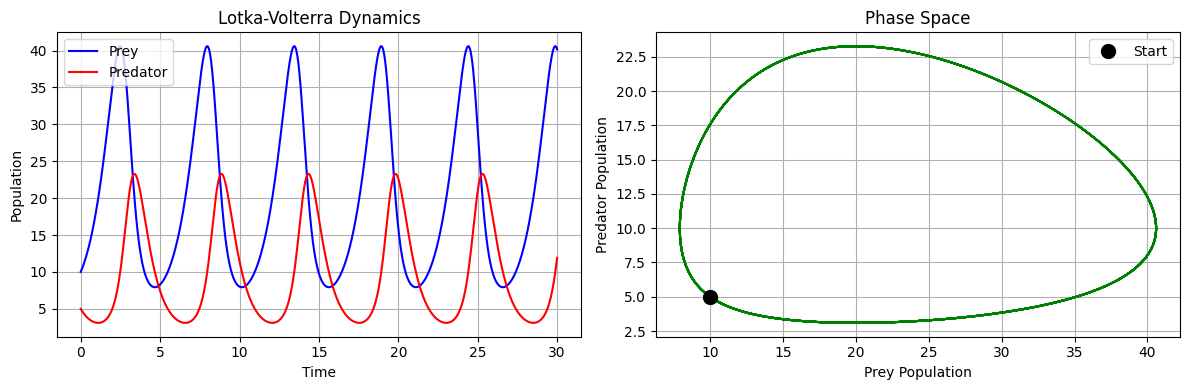

In [5]:
def lotka_volterra(t, state, params):
    """
    Lotka-Volterra predator-prey equations.
    
    state: [x, y] - prey and predator populations
    params: [alpha, beta, delta, gamma]
    """
    x, y = state
    alpha, beta, delta, gamma = params
    
    dx_dt = alpha * x - beta * x * y
    dy_dt = delta * x * y - gamma * y
    
    return jnp.array([dx_dt, dy_dt])

# Parameters
params = jnp.array([1.0, 0.1, 0.075, 1.5])  # alpha, beta, delta, gamma
y0_lv = jnp.array([10.0, 5.0])  # Initial populations

# Solve
t_lv, y_lv = rk4_solve(lotka_volterra, y0_lv, (0.0, 30.0), 1000, params)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(t_lv, y_lv[:, 0], 'b-', label='Prey')
plt.plot(t_lv, y_lv[:, 1], 'r-', label='Predator')
plt.xlabel('Time')
plt.ylabel('Population')
plt.title('Lotka-Volterra Dynamics')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(y_lv[:, 0], y_lv[:, 1], 'g-')
plt.plot(y0_lv[0], y0_lv[1], 'ko', markersize=10, label='Start')
plt.xlabel('Prey Population')
plt.ylabel('Predator Population')
plt.title('Phase Space')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## 5. Differentiating Through ODE Solutions

One of the most powerful features of JAX is the ability to **differentiate through ODE solutions**. This enables:

- Parameter estimation from data
- Optimal control
- Sensitivity analysis
- Neural ODEs

### How it works:
Because our ODE solver uses JAX primitives (`lax.scan`), gradients flow automatically through the entire integration!

In [6]:
# Let's compute the gradient of the final prey population w.r.t. parameters

def final_prey_population(params):
    """Returns final prey population given parameters."""
    _, y = rk4_solve(lotka_volterra, y0_lv, (0.0, 30.0), 500, params)
    return y[-1, 0]  # Final prey count

# Compute gradient
grad_params = grad(final_prey_population)(params)

print("Gradient of final prey population w.r.t. parameters:")
print(f"  d(prey)/d(alpha) = {grad_params[0]:.4f}  (prey growth rate)")
print(f"  d(prey)/d(beta)  = {grad_params[1]:.4f}  (predation rate)")
print(f"  d(prey)/d(delta) = {grad_params[2]:.4f}  (predator growth)")
print(f"  d(prey)/d(gamma) = {grad_params[3]:.4f}  (predator death rate)")

Gradient of final prey population w.r.t. parameters:
  d(prey)/d(alpha) = -94.5517  (prey growth rate)
  d(prey)/d(beta)  = -232.9485  (predation rate)
  d(prey)/d(delta) = -1207.4862  (predator growth)
  d(prey)/d(gamma) = -15.6146  (predator death rate)


In [7]:
# Verify gradient numerically
eps = 1e-5
numerical_grad = []
for i in range(4):
    params_plus = params.at[i].set(params[i] + eps)
    params_minus = params.at[i].set(params[i] - eps)
    numerical_grad.append(
        (final_prey_population(params_plus) - final_prey_population(params_minus)) / (2 * eps)
    )

print("\nNumerical vs Automatic Differentiation:")
for i, (name, num, auto) in enumerate(zip(
    ['alpha', 'beta', 'delta', 'gamma'],
    numerical_grad,
    grad_params
)):
    print(f"  {name}: numerical={num:.4f}, AD={auto:.4f}, diff={abs(num-auto):.2e}")


Numerical vs Automatic Differentiation:
  alpha: numerical=-94.5517, AD=-94.5517, diff=2.45e-06
  beta: numerical=-232.9485, AD=-232.9485, diff=2.11e-05
  delta: numerical=-1207.4858, AD=-1207.4862, diff=3.94e-04
  gamma: numerical=-15.6146, AD=-15.6146, diff=3.36e-07


## 6. Parameter Estimation

A common task is estimating ODE parameters from noisy data. We can use gradient-based optimization!

### Problem Setup:
1. Generate "true" data with known parameters
2. Add noise
3. Estimate parameters by minimizing the difference between model predictions and data

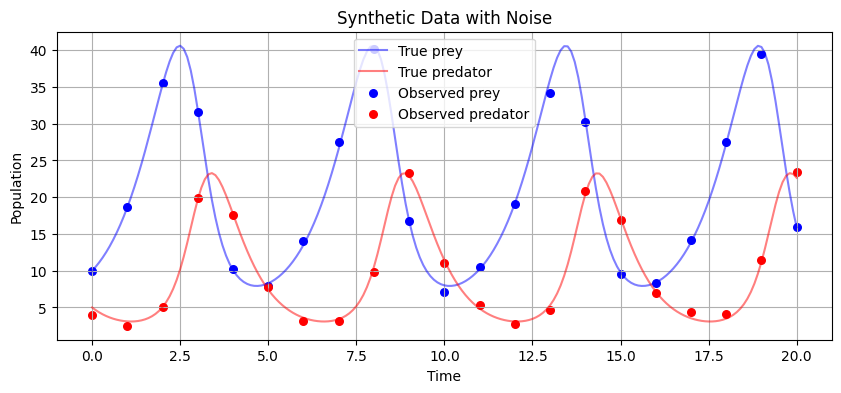

In [8]:
# Generate "true" data
true_params = jnp.array([1.0, 0.1, 0.075, 1.5])
t_data, y_data = rk4_solve(lotka_volterra, y0_lv, (0.0, 20.0), 200, true_params)

# Add noise
key = jax.random.PRNGKey(42)
noise = jax.random.normal(key, y_data.shape) * 0.5
y_noisy = y_data + noise

# Subsample for "observations"
obs_indices = jnp.arange(0, 201, 10)  # Every 10th point
t_obs = t_data[obs_indices]
y_obs = y_noisy[obs_indices]

plt.figure(figsize=(10, 4))
plt.plot(t_data, y_data[:, 0], 'b-', alpha=0.5, label='True prey')
plt.plot(t_data, y_data[:, 1], 'r-', alpha=0.5, label='True predator')
plt.scatter(t_obs, y_obs[:, 0], c='b', s=30, label='Observed prey')
plt.scatter(t_obs, y_obs[:, 1], c='r', s=30, label='Observed predator')
plt.xlabel('Time')
plt.ylabel('Population')
plt.title('Synthetic Data with Noise')
plt.legend()
plt.grid(True)
plt.show()

In [9]:
def loss_function(params, t_obs, y_obs, y0):
    """
    Mean squared error between model predictions and observations.
    """
    # Solve ODE with current parameters
    t_full, y_full = rk4_solve(lotka_volterra, y0, (0.0, 20.0), 200, params)
    
    # Extract predictions at observation times
    y_pred = y_full[obs_indices]
    
    # MSE loss
    return jnp.mean((y_pred - y_obs) ** 2)

# JIT compile loss and gradient
loss_and_grad = jit(jax.value_and_grad(loss_function))

# Initial guess (wrong parameters)
params_init = jnp.array([1.5, 0.05, 0.1, 1.0])

# Adam optimizer (simple implementation)
def adam_update(params, grads, m, v, t, lr=0.01, beta1=0.9, beta2=0.999, eps=1e-8):
    m = beta1 * m + (1 - beta1) * grads
    v = beta2 * v + (1 - beta2) * grads**2
    m_hat = m / (1 - beta1**t)
    v_hat = v / (1 - beta2**t)
    params = params - lr * m_hat / (jnp.sqrt(v_hat) + eps)
    return params, m, v

# Run optimization
params = params_init
m = jnp.zeros_like(params)
v = jnp.zeros_like(params)

losses = []
param_history = [params]

for i in range(500):
    loss, grads = loss_and_grad(params, t_obs, y_obs, y0_lv)
    params, m, v = adam_update(params, grads, m, v, i + 1, lr=0.01)
    losses.append(loss)
    param_history.append(params)
    
    if i % 100 == 0:
        print(f"Iter {i:3d}: loss = {loss:.4f}, params = {params}")

print(f"\nFinal loss: {losses[-1]:.4f}")
print(f"Estimated params: {params}")
print(f"True params:      {true_params}")

Iter   0: loss = 597.3734, params = [1.49 0.06 0.09 0.99]


Iter 100: loss = 6.7464, params = [1.40414412 0.1610956  0.05109155 1.00733789]


Iter 200: loss = 5.5248, params = [1.35134688 0.14988996 0.05339044 1.05118675]


Iter 300: loss = 4.1141, params = [1.28519862 0.1388073  0.05647076 1.1130082 ]


Iter 400: loss = 2.7733, params = [1.21699062 0.12814908 0.06004305 1.18521159]



Final loss: 1.7321
Estimated params: [1.15577835 0.119258   0.06367057 1.25877098]
True params:      [1.    0.1   0.075 1.5  ]


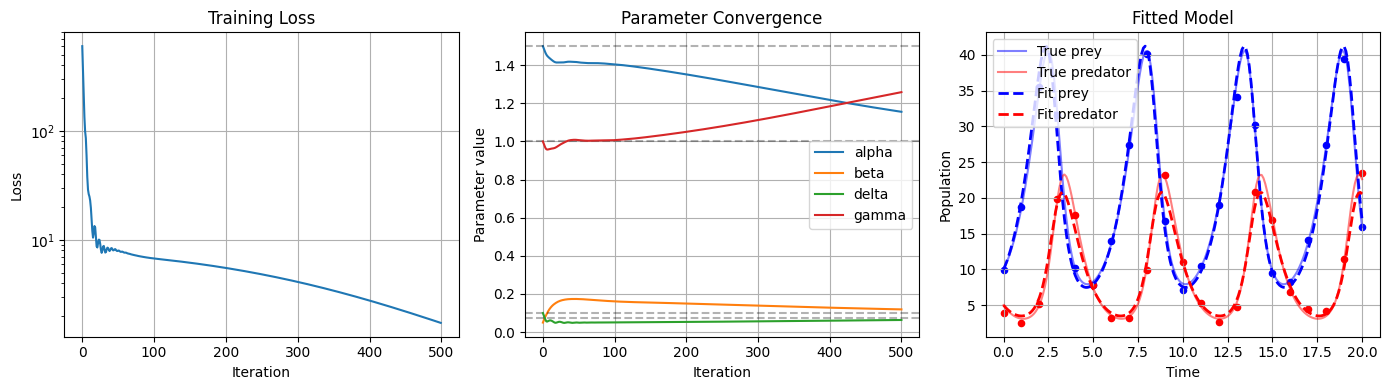

In [10]:
# Visualize results
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Loss curve
axes[0].semilogy(losses)
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss')
axes[0].grid(True)

# Parameter convergence
param_history = jnp.array(param_history)
for i, name in enumerate(['alpha', 'beta', 'delta', 'gamma']):
    axes[1].plot(param_history[:, i], label=name)
    axes[1].axhline(y=true_params[i], color='k', linestyle='--', alpha=0.3)
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Parameter value')
axes[1].set_title('Parameter Convergence')
axes[1].legend()
axes[1].grid(True)

# Final fit
_, y_fit = rk4_solve(lotka_volterra, y0_lv, (0.0, 20.0), 200, params)
axes[2].plot(t_data, y_data[:, 0], 'b-', alpha=0.5, label='True prey')
axes[2].plot(t_data, y_data[:, 1], 'r-', alpha=0.5, label='True predator')
axes[2].plot(t_data, y_fit[:, 0], 'b--', linewidth=2, label='Fit prey')
axes[2].plot(t_data, y_fit[:, 1], 'r--', linewidth=2, label='Fit predator')
axes[2].scatter(t_obs, y_obs[:, 0], c='b', s=20)
axes[2].scatter(t_obs, y_obs[:, 1], c='r', s=20)
axes[2].set_xlabel('Time')
axes[2].set_ylabel('Population')
axes[2].set_title('Fitted Model')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

## 7. Stiff ODEs and Chemical Kinetics

**Stiff ODEs** have widely varying time scales, making them challenging to solve with explicit methods like RK4.

A classic example is the **Robertson chemical kinetics** problem:

$$\frac{dy_1}{dt} = -0.04 y_1 + 10^4 y_2 y_3$$
$$\frac{dy_2}{dt} = 0.04 y_1 - 10^4 y_2 y_3 - 3 \times 10^7 y_2^2$$
$$\frac{dy_3}{dt} = 3 \times 10^7 y_2^2$$

The rate constants span 11 orders of magnitude!

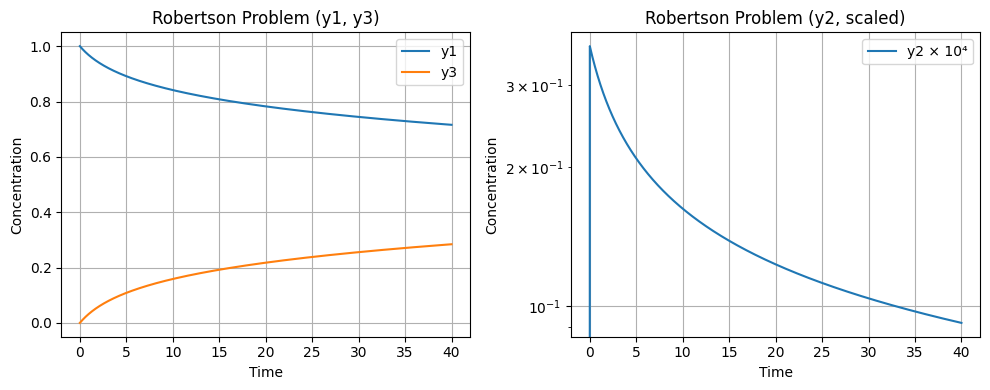

Mass conservation: 1.0000000000 (should be 1.0)


In [11]:
def robertson(t, y, params):
    """Robertson chemical kinetics (stiff ODE)."""
    k1, k2, k3 = params
    y1, y2, y3 = y
    
    dy1 = -k1 * y1 + k2 * y2 * y3
    dy2 = k1 * y1 - k2 * y2 * y3 - k3 * y2**2
    dy3 = k3 * y2**2
    
    return jnp.array([dy1, dy2, dy3])

params_rob = jnp.array([0.04, 1e4, 3e7])
y0_rob = jnp.array([1.0, 0.0, 0.0])

# Solve with many steps (needed for stiff problems with explicit methods)
t_rob, y_rob = rk4_solve(robertson, y0_rob, (0.0, 40.0), 100000, params_rob)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(t_rob, y_rob[:, 0], label='y1')
plt.plot(t_rob, y_rob[:, 2], label='y3')
plt.xlabel('Time')
plt.ylabel('Concentration')
plt.title('Robertson Problem (y1, y3)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.semilogy(t_rob, y_rob[:, 1] * 1e4, label='y2 × 10⁴')
plt.xlabel('Time')
plt.ylabel('Concentration')
plt.title('Robertson Problem (y2, scaled)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"Mass conservation: {y_rob[-1].sum():.10f} (should be 1.0)")

## 8. Implicit Methods for Stiff ODEs

For stiff problems, **implicit methods** are more stable. The simplest is the **Backward Euler** method:

$$y_{n+1} = y_n + h \cdot f(t_{n+1}, y_{n+1})$$

This requires solving a nonlinear equation at each step. We can use Newton's method.

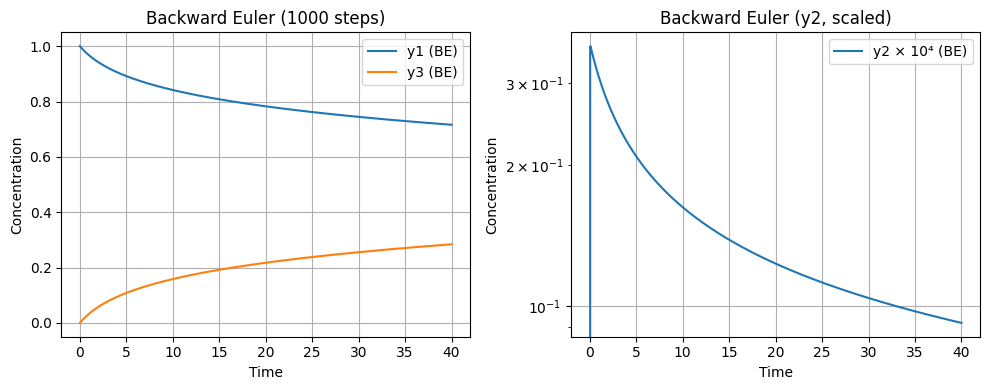

Mass conservation: 1.0000000000 (should be 1.0)

Comparison: RK4 needed 100,000 steps, Backward Euler only 1,000!


In [12]:
def backward_euler_step(f, t_new, y_old, h, args, max_iter=10, tol=1e-10):
    """
    Backward Euler step using Newton iteration.
    
    Solves: y_new = y_old + h * f(t_new, y_new)
    Rearranged: g(y) = y - y_old - h * f(t_new, y) = 0
    """
    def residual(y):
        return y - y_old - h * f(t_new, y, *args)
    
    # Initial guess from forward Euler
    y = y_old + h * f(t_new - h, y_old, *args)
    
    # Newton iteration
    def newton_step(carry, _):
        y, converged = carry
        r = residual(y)
        J = jacfwd(residual)(y)
        
        # Solve J @ dy = -r
        dy = jnp.linalg.solve(J, -r)
        y_new = y + dy
        
        # Check convergence
        converged = jnp.linalg.norm(dy) < tol
        
        return (y_new, converged), None
    
    (y_final, _), _ = lax.scan(newton_step, (y, False), None, length=max_iter)
    return y_final

def backward_euler_solve(f, y0, t_span, n_steps, *args):
    """Solve ODE using Backward Euler method."""
    t_start, t_end = t_span
    h = (t_end - t_start) / n_steps
    t_values = jnp.linspace(t_start, t_end, n_steps + 1)
    
    def scan_fn(y, t_new):
        y_new = backward_euler_step(f, t_new, y, h, args)
        return y_new, y_new
    
    _, y_values = lax.scan(scan_fn, y0, t_values[1:])
    y_values = jnp.concatenate([y0[None], y_values])
    
    return t_values, y_values

# Solve Robertson problem with backward Euler (fewer steps needed!)
t_be, y_be = backward_euler_solve(robertson, y0_rob, (0.0, 40.0), 1000, params_rob)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(t_be, y_be[:, 0], label='y1 (BE)')
plt.plot(t_be, y_be[:, 2], label='y3 (BE)')
plt.xlabel('Time')
plt.ylabel('Concentration')
plt.title('Backward Euler (1000 steps)')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.semilogy(t_be, y_be[:, 1] * 1e4, label='y2 × 10⁴ (BE)')
plt.xlabel('Time')
plt.ylabel('Concentration')
plt.title('Backward Euler (y2, scaled)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"Mass conservation: {y_be[-1].sum():.10f} (should be 1.0)")
print(f"\nComparison: RK4 needed 100,000 steps, Backward Euler only 1,000!")

## 9. Sensitivity Analysis of ODEs

The **sensitivity** $s_i = \frac{\partial y}{\partial p_i}$ tells us how the solution changes with respect to parameters.

There are two approaches:

### 9.1 Forward Sensitivity (solve augmented system)

Differentiate the ODE $\frac{dy}{dt} = f(t, y, p)$ w.r.t. $p$:

$$\frac{d}{dt}\left(\frac{\partial y}{\partial p}\right) = \frac{\partial f}{\partial y}\frac{\partial y}{\partial p} + \frac{\partial f}{\partial p}$$

In [13]:
def forward_sensitivity_system(t, augmented_state, params):
    """
    Augmented system for forward sensitivity analysis.
    
    augmented_state contains:
    - y: the state (first n_y elements)
    - S: the sensitivity matrix dy/dp (flattened, remaining elements)
    """
    n_y = 2  # Number of state variables (Lotka-Volterra)
    n_p = 4  # Number of parameters
    
    y = augmented_state[:n_y]
    S = augmented_state[n_y:].reshape(n_y, n_p)
    
    # Original ODE
    f = lotka_volterra(t, y, params)
    
    # Jacobians
    df_dy = jacfwd(lambda y_: lotka_volterra(t, y_, params))(y)
    df_dp = jacfwd(lambda p: lotka_volterra(t, y, p))(params)
    
    # Sensitivity ODE: dS/dt = df/dy @ S + df/dp
    dS_dt = df_dy @ S + df_dp
    
    return jnp.concatenate([f, dS_dt.flatten()])

# Initial conditions: y0, and zero sensitivities
S0 = jnp.zeros((2, 4))  # Initial sensitivity is zero
augmented_y0 = jnp.concatenate([y0_lv, S0.flatten()])

# Solve
t_sens, y_sens = rk4_solve(forward_sensitivity_system, augmented_y0, (0.0, 20.0), 500, true_params)

# Extract sensitivity
y_solution = y_sens[:, :2]
S_final = y_sens[-1, 2:].reshape(2, 4)

print("Forward sensitivity at t=20:")
print("\ndx/dp (prey sensitivity to parameters):")
for i, name in enumerate(['alpha', 'beta', 'delta', 'gamma']):
    print(f"  d(prey)/d({name}) = {S_final[0, i]:+.4f}")

print("\ndy/dp (predator sensitivity to parameters):")
for i, name in enumerate(['alpha', 'beta', 'delta', 'gamma']):
    print(f"  d(pred)/d({name}) = {S_final[1, i]:+.4f}")

Forward sensitivity at t=20:

dx/dp (prey sensitivity to parameters):
  d(prey)/d(alpha) = -208.6077
  d(prey)/d(beta) = -72.6854
  d(prey)/d(delta) = -893.1252
  d(prey)/d(gamma) = -79.2722

dy/dp (predator sensitivity to parameters):
  d(pred)/d(alpha) = -45.1292
  d(pred)/d(beta) = -341.0425
  d(pred)/d(delta) = -414.8330
  d(pred)/d(gamma) = -19.1154


### 9.2 Adjoint Sensitivity (more efficient for many parameters)

JAX's reverse-mode autodiff automatically implements adjoint sensitivity when you differentiate through `lax.scan`. This is more efficient when you have many parameters but few outputs.

In [14]:
# Using JAX's automatic adjoint through lax.scan
def final_state_loss(params):
    """Sum of final populations."""
    _, y = rk4_solve(lotka_volterra, y0_lv, (0.0, 20.0), 500, params)
    return y[-1, 0] + y[-1, 1]

# This uses adjoint method automatically!
adjoint_grad = grad(final_state_loss)(true_params)

print("Adjoint sensitivity (d(prey + pred)/dp at t=20):")
for i, name in enumerate(['alpha', 'beta', 'delta', 'gamma']):
    forward_sens = S_final[0, i] + S_final[1, i]  # Sum of sensitivities
    print(f"  d(sum)/d({name}): adjoint = {adjoint_grad[i]:+.4f}, forward = {forward_sens:+.4f}")

Adjoint sensitivity (d(prey + pred)/dp at t=20):
  d(sum)/d(alpha): adjoint = -253.7370, forward = -253.7370
  d(sum)/d(beta): adjoint = -413.7279, forward = -413.7279
  d(sum)/d(delta): adjoint = -1307.9583, forward = -1307.9583
  d(sum)/d(gamma): adjoint = -98.3877, forward = -98.3877


## 10. Using diffrax Library

For production use, the **diffrax** library provides high-quality, differentiable ODE solvers with:

- Adaptive step size control
- Multiple solver types (Dopri5, Tsit5, implicit methods)
- Event handling
- Efficient adjoints

```python
# Install with: pip install diffrax
import diffrax

def vector_field(t, y, args):
    return lotka_volterra(t, y, args)

term = diffrax.ODETerm(vector_field)
solver = diffrax.Dopri5()
solution = diffrax.diffeqsolve(
    term,
    solver,
    t0=0,
    t1=20,
    dt0=0.1,
    y0=y0_lv,
    args=true_params,
    saveat=diffrax.SaveAt(ts=jnp.linspace(0, 20, 100))
)
```

## 11. Neural ODEs (Introduction)

**Neural ODEs** replace the right-hand side $f(t, y)$ with a neural network:

$$\frac{dy}{dt} = \text{NN}_\theta(t, y)$$

This creates a continuous-depth neural network that can be trained end-to-end through the ODE solver.

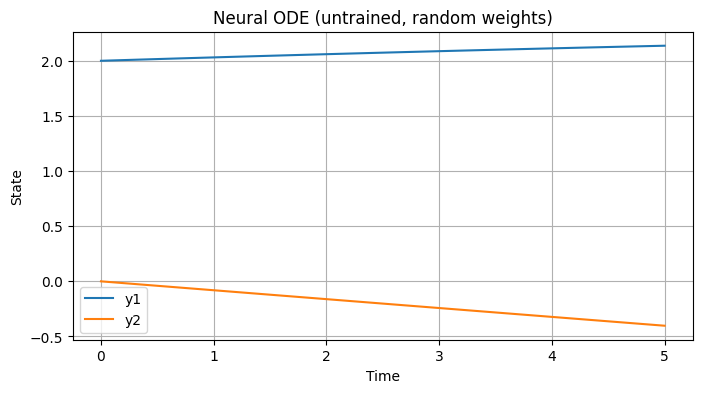

In [15]:
def neural_ode_field(t, y, params):
    """
    Simple neural network for ODE right-hand side.
    
    params: dict with 'W1', 'b1', 'W2', 'b2'
    """
    W1, b1, W2, b2 = params['W1'], params['b1'], params['W2'], params['b2']
    
    # Simple 2-layer MLP
    h = jnp.tanh(W1 @ y + b1)
    return W2 @ h + b2

def init_neural_ode_params(key, input_dim, hidden_dim):
    """Initialize neural ODE parameters."""
    keys = jax.random.split(key, 4)
    scale = 0.1
    return {
        'W1': jax.random.normal(keys[0], (hidden_dim, input_dim)) * scale,
        'b1': jnp.zeros(hidden_dim),
        'W2': jax.random.normal(keys[2], (input_dim, hidden_dim)) * scale,
        'b2': jnp.zeros(input_dim),
    }

# Initialize
key = jax.random.PRNGKey(0)
node_params = init_neural_ode_params(key, input_dim=2, hidden_dim=32)

# Solve neural ODE
def solve_neural_ode(params, y0, t_span, n_steps):
    t_start, t_end = t_span
    h = (t_end - t_start) / n_steps
    t_values = jnp.linspace(t_start, t_end, n_steps + 1)
    
    def scan_fn(y, t):
        # RK4 step
        k1 = neural_ode_field(t, y, params)
        k2 = neural_ode_field(t + h/2, y + h*k1/2, params)
        k3 = neural_ode_field(t + h/2, y + h*k2/2, params)
        k4 = neural_ode_field(t + h, y + h*k3, params)
        y_new = y + (h/6) * (k1 + 2*k2 + 2*k3 + k4)
        return y_new, y_new
    
    _, y_values = lax.scan(scan_fn, y0, t_values[:-1])
    y_values = jnp.concatenate([y0[None], y_values])
    
    return t_values, y_values

# Test forward pass
y0_node = jnp.array([2.0, 0.0])
t_node, y_node = solve_neural_ode(node_params, y0_node, (0.0, 5.0), 100)

plt.figure(figsize=(8, 4))
plt.plot(t_node, y_node[:, 0], label='y1')
plt.plot(t_node, y_node[:, 1], label='y2')
plt.xlabel('Time')
plt.ylabel('State')
plt.title('Neural ODE (untrained, random weights)')
plt.legend()
plt.grid(True)
plt.show()

In [16]:
# Train neural ODE to mimic Lotka-Volterra
# Generate training data
t_train, y_train = rk4_solve(lotka_volterra, y0_lv, (0.0, 10.0), 100, true_params)

def node_loss(params, t_data, y_data):
    """MSE loss for neural ODE."""
    _, y_pred = solve_neural_ode(params, y_data[0], (t_data[0], t_data[-1]), len(t_data) - 1)
    return jnp.mean((y_pred - y_data) ** 2)

# Training loop
node_loss_and_grad = jit(jax.value_and_grad(node_loss))

# Initialize optimizer state for each parameter
m = jax.tree.map(jnp.zeros_like, node_params)
v = jax.tree.map(jnp.zeros_like, node_params)

def adam_update_tree(params, grads, m, v, t, lr=0.01):
    beta1, beta2, eps = 0.9, 0.999, 1e-8
    m = jax.tree.map(lambda m_, g: beta1 * m_ + (1 - beta1) * g, m, grads)
    v = jax.tree.map(lambda v_, g: beta2 * v_ + (1 - beta2) * g**2, v, grads)
    m_hat = jax.tree.map(lambda m_: m_ / (1 - beta1**t), m)
    v_hat = jax.tree.map(lambda v_: v_ / (1 - beta2**t), v)
    params = jax.tree.map(
        lambda p, m_, v_: p - lr * m_ / (jnp.sqrt(v_) + eps),
        params, m_hat, v_hat
    )
    return params, m, v

losses = []
for i in range(300):
    loss, grads = node_loss_and_grad(node_params, t_train, y_train)
    node_params, m, v = adam_update_tree(node_params, grads, m, v, i + 1, lr=0.01)
    losses.append(loss)
    
    if i % 50 == 0:
        print(f"Iter {i}: loss = {loss:.6f}")

print(f"\nFinal loss: {losses[-1]:.6f}")

Iter 0: loss = 163.206654
Iter 50: loss = 98.864786


Iter 100: loss = 96.473752
Iter 150: loss = 92.174207


Iter 200: loss = 88.112829
Iter 250: loss = 85.252522

Final loss: 83.448991


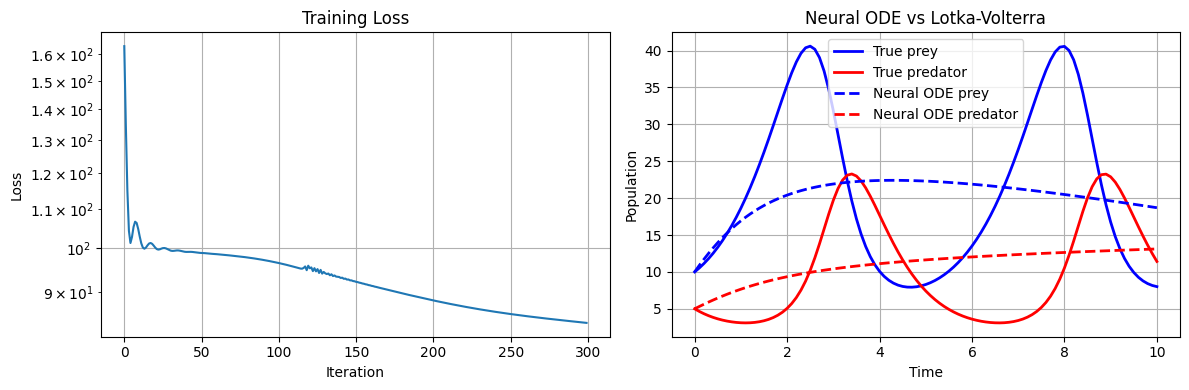

In [17]:
# Visualize trained neural ODE
_, y_node_trained = solve_neural_ode(node_params, y0_lv, (0.0, 10.0), 100)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].semilogy(losses)
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss')
axes[0].grid(True)

axes[1].plot(t_train, y_train[:, 0], 'b-', label='True prey', linewidth=2)
axes[1].plot(t_train, y_train[:, 1], 'r-', label='True predator', linewidth=2)
axes[1].plot(t_train, y_node_trained[:, 0], 'b--', label='Neural ODE prey', linewidth=2)
axes[1].plot(t_train, y_node_trained[:, 1], 'r--', label='Neural ODE predator', linewidth=2)
axes[1].set_xlabel('Time')
axes[1].set_ylabel('Population')
axes[1].set_title('Neural ODE vs Lotka-Volterra')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Summary

In this notebook, we covered:

1. **Basic ODE solvers** - Euler and RK4 methods using `lax.scan`
2. **Systems of ODEs** - Lotka-Volterra predator-prey model
3. **Differentiating through solutions** - JAX handles this automatically
4. **Parameter estimation** - Fitting ODE parameters to data
5. **Stiff ODEs** - Implicit methods for challenging problems
6. **Sensitivity analysis** - Forward and adjoint methods
7. **Neural ODEs** - Neural networks as ODE right-hand sides

### Key takeaways:

- `lax.scan` is perfect for time-stepping algorithms - efficient and differentiable
- JAX's autodiff flows through the entire ODE solver automatically
- Implicit methods need Newton iteration but handle stiff problems better
- For production use, consider **diffrax** for adaptive step size and efficient adjoints
- Neural ODEs combine deep learning with dynamical systems